In [46]:
#imports
import sys; sys.path.append("..")
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt


In [47]:
with open(r"C:\spike-denoising-synthetic\data\real\_Information.txt") as f:
    print(f.read())

2025/10/06
This folder contains time series data recorded from the saphenous nerve of a rat, including the filtered data signal and the 'ground truth' time points for two single nerve units.
- time_series_2.bin : the time information of the data recordings
- 100_RhythmData_...bin : the data recordings from several relevant channels. This data has been common average referenced (median), and filtered (300-6000Hz), and stimulation artifacts have been blanked (i.e., set to the mean).
- grouped_unit_1.mat : describes the time points of a 'good' unit which has large spikes on multiple data channels
- grouped_unit_2.mat : describes the time points of a 'bad' unit which has spikes on only one data channel

The 'grouped_unit_' files contain a struct, most of which is not useful. The relevant information is under the 'CH**' field (i.e., whichever field the spike was recorded on, there may be multiple of these fields). Under the 'CH**' field is the 'aligned_zc_locs' which will describe when (i.e

In [48]:
with open(r"C:\spike-denoising-synthetic\data\real\example_script.m") as f:
    print(f.read())

% Script to load example data

% Change the string below to navigate to the correct folder/directory
folder_path = "C:\Users\...\2025-02-13 - Data for sharing";

% Load the timestamps
fid = fopen(folder_path + "\time_series_2.bin");
time_stamps = fread(fid,inf,'double');
fclose(fid);

% Load the grouped unit struct
grouped_unit = load(folder_path + "\grouped_unit_1.mat");
field_names = fieldnames(grouped_unit);

% For each of the channels ('CH**'), graph a period of time to show spikes
channels_of_interest = field_names(contains(field_names,"CH"));
time_block_of_interest = [3000 3360]; % the time period we will graph
selected_timestamps = time_stamps(time_stamps>time_block_of_interest(1) & time_stamps<time_block_of_interest(2));

figure;
hold on;
for i=1:length(channels_of_interest)
    % load the data recording
    if ~isfile(folder_path + "\100_RhythmData_"+channels_of_interest{i}+"_2_filtered_blanked.bin")
        continue
    end
    fid = fopen(folder_path + "\100_RhythmData_"+cha

In [49]:
path = r"C:\spike-denoising-synthetic\data\real"

# read the first 2 million samples of CH 19
n_read = 2_000_000
ch19 = np.fromfile(path + r"\100_RhythmData_CH19_2_filtered_blanked.bin",
                   dtype='<f8', count=n_read)

# rad the matching timestamps 
tstamps = np.fromfile(path +  r"\time_series_2.bin",
                      dtype='<f8', count=n_read)

print("ch19 samples:", ch19.shape)
print("ch19 range:", ch19.min(), "to", ch19.max())
print("timestamps range:", tstamps.min(), "to", tstamps.max())
print("first 5 timestamps:", tstamps[:5])

ch19 samples: (2000000,)
ch19 range: -23.76011994785937 to 23.91417943875254
timestamps range: 1.03 to 67.69663333333334
first 5 timestamps: [1.03       1.03003333 1.03006667 1.0301     1.03013333]


In [50]:
print(tstamps[1] - tstamps[0])

3.333333333332966e-05


In [51]:
print("any nan or inf?", np.isnan(ch19).any(), np.isinf(ch19).any())
print("mean:", ch19.mean())
print("std:", ch19.std())
print("max abs value:", np.abs(ch19).max())

any nan or inf? False False
mean: -0.00038347341719193004
std: 4.170475189093898
max abs value: 23.91417943875254


In [52]:
import h5py
print(h5py.__version__)

3.15.1


In [53]:
gt = h5py.File(r"C:\spike-denoising-synthetic\data\real\grouped_unit_1.mat", 'r')
print("keys:", list(gt.keys()))

keys: ['#refs#', '#subsystem#', 'CH10', 'CH14', 'CH19', 'CH25', 'CH3', 'CH30', 'CH9', 'filename', 'group_number', 'primary_channel']


In [54]:
print("fields inside CH19:", list(gt['CH19'].keys()))

fields inside CH19: ['aligned_zc_lats', 'aligned_zc_locs', 'channel', 'config', 'experiment', 'filename', 'highlighted_data_TTLs', 'highlighted_data_lats', 'highlighted_data_logs', 'latencies', 'mech_after', 'mech_before', 'nth_TTL', 'plot_handles', 'probe_axis', 'probe_data', 'spike_plot_data', 'spikes_axis', 'status', 'traces_axis', 'true_locs', 'zc_alignment', 'zc_locs']


In [55]:
zc = gt['CH19']['aligned_zc_locs'][:]
print("shape:", zc.shape)
print("how many spikes:", zc.size)
print("first few:", zc.flatten()[:5])
print("range:", zc.min(), "to", zc.max())

shape: (1, 1623)
how many spikes: 1623
first few: [1754.45036667 1758.45       1762.4505     1766.45126667 1770.45166667]
range: 1754.4503666666667 to 8265.239733333334


In [56]:
zc_times = zc.flatten()   # the 4 spike times, in seconds
print("spike times:", zc_times)

# how far into the file does our loaded chunk reach?
print("chunk covers 0 to", n_read / 30000, "seconds")

spike times: [1754.45036667 1758.45       1762.4505     ... 8257.23826667 8261.23906667
 8265.23973333]
chunk covers 0 to 66.66666666666667 seconds


In [57]:
zc_times = zc.flatten()
print("spike times (s):", zc_times)

spike times (s): [1754.45036667 1758.45       1762.4505     ... 8257.23826667 8261.23906667
 8265.23973333]


In [58]:
fs_real = 30000
t_spike = zc_times[0]                      # first spike time, seconds
idx = int(t_spike * fs_real)               # its sample position in the file

# load a window around it: 15000 samples (~0.5 s) starting a bit before the spike
start = idx - 7500
n_win = 15000
ch19_seg = np.fromfile(
    path + r"\100_RhythmData_CH19_2_filtered_blanked.bin",
    dtype='<f8', count=n_win, offset=start * 8)   # *8 because float64 = 8 bytes

# the spike sits at sample 7500 within this segment
local_idx = idx - start
window = ch19_seg[local_idx-45 : local_idx+45]
print("trough at spike:", window.min())
print("segment std:", ch19_seg.std())
print("trough / std:", window.min() / ch19_seg.std())

trough at spike: -12.073138290313675
segment std: 5.6119061219814546
trough / std: -2.1513435948302866


In [59]:
mad = np.median(np.abs(ch19_seg - np.median(ch19_seg))) / 0.6745
print("trough / MAD:", window.min() / mad)

trough / MAD: -2.296081559392508


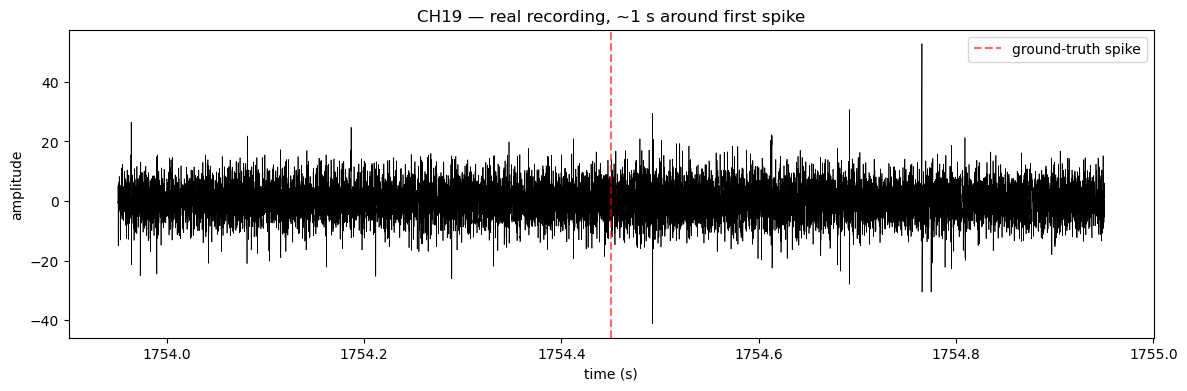

In [60]:
sample_rate = 30000
spike_time = zc_times[0]
idx = int(spike_time * sample_rate)

start = idx - 15000
samples_window = 30000
ch19_seg = np.fromfile(
    path + r"\100_RhythmData_CH19_2_filtered_blanked.bin",
    dtype='<f8', count=samples_window, offset=start * 8)

t_axis = (np.arange(samples_window) + start) / sample_rate

plt.figure(figsize=(14, 4))
plt.plot(t_axis, ch19_seg, 'k', linewidth=0.5)
plt.axvline(spike_time, color='r', linestyle='--', alpha=0.6, label='ground-truth spike')
plt.xlabel('time (s)')
plt.ylabel('amplitude')
plt.title('CH19 — real recording, ~1 s around first spike')
plt.legend()
plt.show()

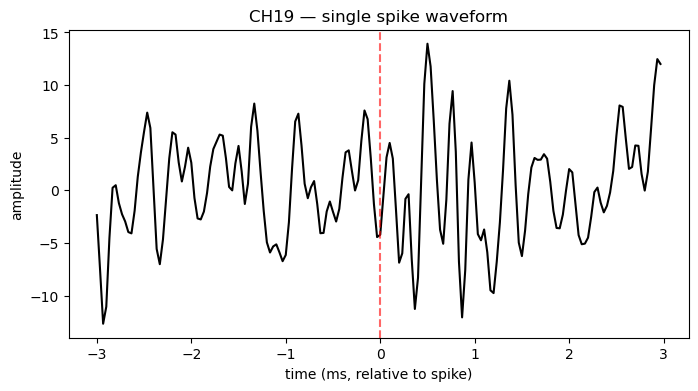

In [61]:
local = idx - start
spike_win = ch19_seg[local-90 : local+90]   # ~6 ms
t_spike_axis = (np.arange(len(spike_win)) - 90) / fs_real * 1000  # ms, centred on spike

plt.figure(figsize=(8, 4))
plt.plot(t_spike_axis, spike_win, 'k')
plt.axvline(0, color='r', linestyle='--', alpha=0.6)
plt.xlabel('time (ms, relative to spike)')
plt.ylabel('amplitude')
plt.title('CH19 — single spike waveform')
plt.show()

In [62]:
print("number of spikes on CH19:", zc_times.size)
print("shape of zc:", zc.shape)
print("size:", zc.size)

number of spikes on CH19: 1623
shape of zc: (1, 1623)
size: 1623


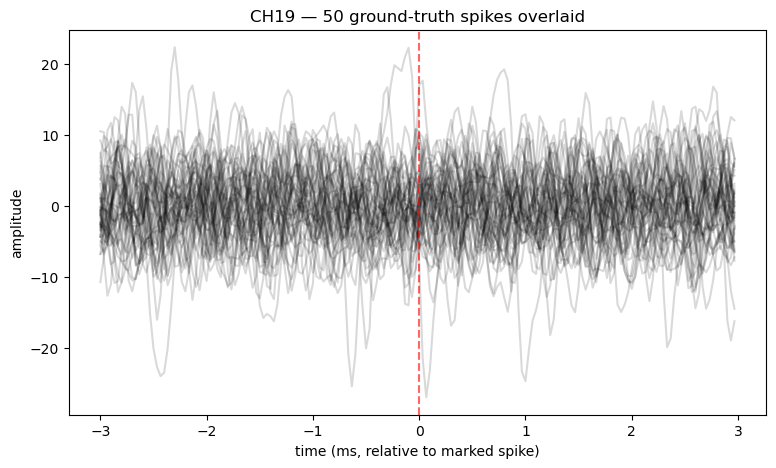

In [63]:
ch19_file = path + r"\100_RhythmData_CH19_2_filtered_blanked.bin"
half = 90                                  # ~3 ms each side at 30 kHz
zc_times = zc.flatten()

plt.figure(figsize=(9, 5))
for st in zc_times[:50]:                    # first 50 spikes
    idx = int(st * sample_rate)
    start = idx - half
    if start < 0:
        continue
    seg = np.fromfile(ch19_file, dtype='<f8', count=2*half, offset=start*8)
    t_ms = (np.arange(len(seg)) - half) / sample_rate * 1000
    plt.plot(t_ms, seg, 'k', alpha=0.15)    # faint, so overlap shows density

plt.axvline(0, color='r', linestyle='--', alpha=0.6)
plt.xlabel('time (ms, relative to marked spike)')
plt.ylabel('amplitude')
plt.title('CH19 — 50 ground-truth spikes overlaid')
plt.show()

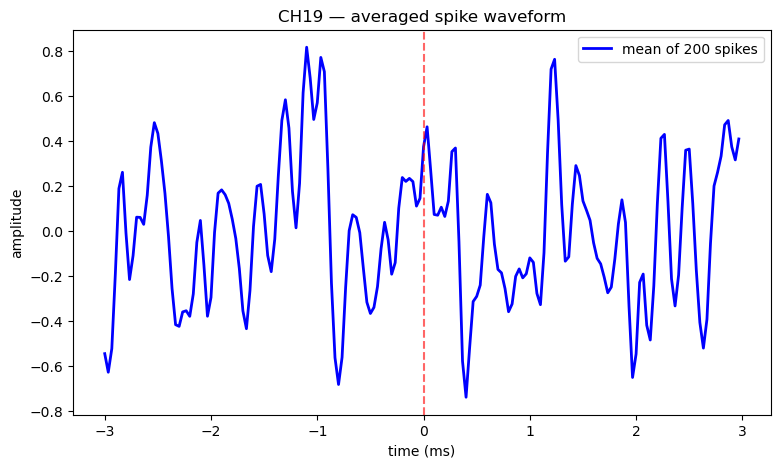

In [64]:
segs = []
for st in zc_times[:200]:
    idx = int(st * sample_rate)
    start = idx - half
    if start < 0:
        continue
    seg = np.fromfile(ch19_file, dtype='<f8', count=2*half, offset=start*8)
    if len(seg) == 2*half:
        segs.append(seg)

segs = np.array(segs)
mean_spike = segs.mean(axis=0)
t_ms = (np.arange(2*half) - half) / sample_rate * 1000

plt.figure(figsize=(9, 5))
plt.plot(t_ms, mean_spike, 'b', linewidth=2, label=f'mean of {len(segs)} spikes')
plt.axvline(0, color='r', linestyle='--', alpha=0.6)
plt.xlabel('time (ms)'); plt.ylabel('amplitude'); plt.legend()
plt.title('CH19 — averaged spike waveform')
plt.show()

In [65]:
# find a gap between two marked spikes
zc_times = zc.flatten()
gap_start_time = zc_times[10] + 0.05   # 50 ms after the 10th spike, likely past its tail
n_quiet = 30000                         # 1 second

idx = int(gap_start_time * sample_rate)
quiet = np.fromfile(ch19_file, dtype='<f8', count=n_quiet, offset=idx*8)

print("std:", quiet.std())
print("max abs:", np.abs(quiet).max())
print("max/std:", np.abs(quiet).max() / quiet.std())

std: 5.302221615719859
max abs: 48.70358713937733
max/std: 9.185505750077


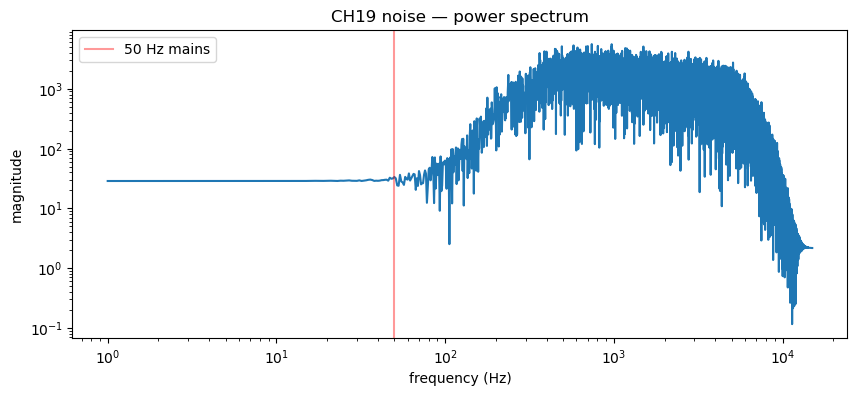

In [66]:
freqs = np.fft.rfftfreq(n_quiet, d=1/sample_rate)
spectrum = np.abs(np.fft.rfft(quiet))

plt.figure(figsize=(10, 4))
plt.loglog(freqs[1:], spectrum[1:])       # log-log shows 1/f as a straight line
plt.xlabel('frequency (Hz)')
plt.ylabel('magnitude')
plt.title('CH19 noise — power spectrum')
plt.axvline(50, color='r', alpha=0.4, label='50 Hz mains')
plt.legend()
plt.show()

In [67]:
zc_times = zc.flatten()

# try several gaps, find one that's actually quiet
for k in [50, 100, 200, 500]:
    gap_time = zc_times[k] + 0.1        # 100 ms after spike k
    idx = int(gap_time * sample_rate)
    quiet = np.fromfile(ch19_file, dtype='<f8', count=30000, offset=idx*8)
    ratio = np.abs(quiet).max() / quiet.std()
    print(f"gap after spike {k}: std={quiet.std():.2f}, max/std={ratio:.1f}")

gap after spike 50: std=5.25, max/std=9.4
gap after spike 100: std=5.34, max/std=10.6
gap after spike 200: std=5.29, max/std=9.6
gap after spike 500: std=5.23, max/std=6.1


# Detect spikes

In [68]:
print("path:", path)
print("zc shape:", zc.shape)

path: C:\spike-denoising-synthetic\data\real
zc shape: (1, 1623)


In [69]:
def detect_spikes(data, fs, k=4, noise_std=None):
    if noise_std is None:
        noise_std = np.median(np.abs(data)) / 0.6745 # MAD
    threshold = -k * noise_std
    below = data < threshold#
    crossings = np.where(np.diff(below.astype(int)) == 1)[0] + 1
    return crossings / fs

In [75]:
import importlib, src.evaluate
importlib.reload(src.evaluate)
from src.evaluate import detect_spikes, score_detections

In [76]:
import inspect
print(inspect.getsource(detect_spikes))

def detect_spikes(data, fs, k=4, noise_std=None):
    if noise_std is None:
        noise_std = np.median(np.abs(data)) / 0.6745
    threshold = -k * noise_std
    below = data < threshold
    crossings = np.where(np.diff(below.astype(int)) == 1)[0] + 1
    return crossings / fs



In [77]:
phase1_start_ttl = 796  #phase 1 start TTL from the table
phase1_start_time = 3170.59  # phase 1 start time in seconds from the table
freq = 0.25   # stimulus freq (Hz)

t_start = phase1_start_time + (900 - phase1_start_ttl) / freq
t_end = t_start + 30  # 30 s window to begin

print("TTL 900 is at", t_start, "seconds")

TTL 900 is at 3586.59 seconds


In [72]:
t_end = t_start + 30

sample_rate = 30000
ch19_file = path + r"\100_RhythmData_CH19_2_filtered_blanked.bin"

start_idx = int(t_start * sample_rate)
n_win = int((t_end - t_start) * sample_rate)
ch19_win = np.fromfile(ch19_file, dtype='<f8', count=n_win, offset=start_idx * 8)

print("samples:", ch19_win.shape)
print("noise (MAD):", np.median(np.abs(ch19_win)) / 0.6745)

samples: (900000,)
noise (MAD): 4.951353256885254


In [73]:
zc_times = zc.flatten()
gt_in_win = zc_times[(zc_times >= t_start) & (zc_times <= t_end)]
print("ground-truth spikes in window:", len(gt_in_win))

ground-truth spikes in window: 7


In [74]:
# K sweep
for k in [1.5, 2, 2.5, 3, 4]:
    det = detect_spikes(ch19_win, sample_rate, k=k) + t_start
    p, r, f = score_detections(det, gt_in_win, tolerance=0.001)
    print(f"k={k}: detected {len(det):4d}, precision {p:.3f}, recall {r:.3f}, F1 {f:.3f}")

k=1.5: detected 25332, precision 0.000, recall 1.000, F1 0.001
k=2: detected 11548, precision 0.001, recall 0.857, F1 0.001
k=2.5: detected 5065, precision 0.001, recall 0.571, F1 0.002
k=3: detected 2257, precision 0.001, recall 0.429, F1 0.003
k=4: detected  605, precision 0.002, recall 0.143, F1 0.003


In [78]:
for tol in [0.001, 0.002, 0.005]:
    det = detect_spikes(ch19_win, sample_rate, k=3) + t_start
    p, r, f = score_detections(det, gt_in_win, tolerance=tol)
    print(f"tol={tol*1000:.0f}ms: precision {p:.4f}, recall {r:.3f}, F1 {f:.3f}")

tol=1ms: precision 0.0013, recall 0.429, F1 0.003
tol=2ms: precision 0.0013, recall 0.429, F1 0.003
tol=5ms: precision 0.0018, recall 0.571, F1 0.004


In [79]:
noise_mad = np.median(np.abs(ch19_win)) / 0.6745
print("noise (MAD):", noise_mad)

# actual trough at each ground-truth spike
for st in gt_in_win:
    local_idx = int((st - t_start) * sample_rate)     # position within the window
    seg = ch19_win[local_idx-45 : local_idx+45]        # ±1.5 ms around the marked time
    if len(seg) > 0:
        print(f"spike trough: {seg.min():.1f}   ratio to noise: {seg.min()/noise_mad:.2f}")

noise (MAD): 4.951353256885254
spike trough: -10.5   ratio to noise: -2.12
spike trough: -17.9   ratio to noise: -3.62
spike trough: -25.5   ratio to noise: -5.16
spike trough: -15.1   ratio to noise: -3.04
spike trough: -14.1   ratio to noise: -2.85
spike trough: -7.6   ratio to noise: -1.53
spike trough: -10.9   ratio to noise: -2.20


### Real-data detection baseline — CH19, TTL 900 window

Threshold detection (MAD noise estimate) swept over k=1.5–4.
- Recall 0.4–0.6 across the sweep — the detector finds ~half the unit's spikes.
- Precision ≈ 0 thousands of false detections from other units and noise.
- F1 ≈ 0 at every threshold and tolerance (±1 to ±5 ms).

The unit's spikes ARE detectable (they cross threshold), but on a single channel they cannot be separated from other units and noise. No threshold works: shallow floods with noise (20,000+ detections), deep still leaves ~700 false positives for 7 real spikes.

Confirms the synthetic weak channel finding on real data: a spike ~2× the noise cannot be isolated by single-channel threshold detection. This is the motivation for (a) denoising to lift the spike above noise, and (b) multiple contacts to separate the unit by its spatial fingerprint.

## Extract spike template following Troglio et al. (2026)

In [80]:
ch19_file = path + r"\100_RhythmData_CH19_2_filtered_blanked.bin"
zc_times = zc.flatten()
half = 45                        # 90-sample template

segs = []
for st in zc_times[:300]:        # first 300 spikes
    idx = int(st * sample_rate)
    start = idx - half
    if start < 0:
        continue
    seg = np.fromfile(ch19_file, dtype='<f8', count=2*half, offset=start*8)
    if len(seg) == 2*half:
        segs.append(seg)

segs = np.array(segs)
template = segs.mean(axis=0)      # THE TEMPLATE — average spike shape

print("averaged", len(segs), "spikes")
print("template length:", len(template))
print("template trough:", template.min())
print("noise (MAD) for scale:", np.median(np.abs(segs)) / 0.6745)

averaged 300 spikes
template length: 90
template trough: -0.5863467889865518
noise (MAD) for scale: 4.831941964244899


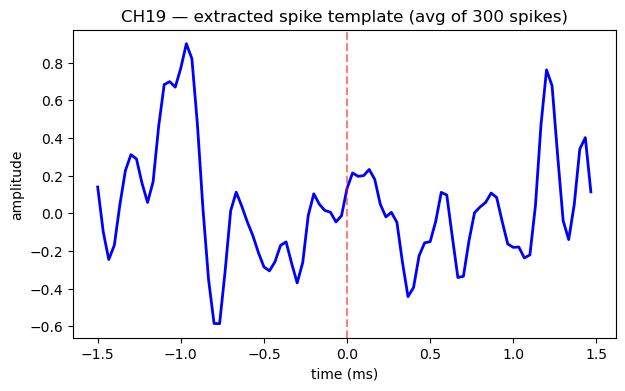

In [81]:
t_ms = (np.arange(len(template)) - half) / sample_rate * 1000
plt.figure(figsize=(7,4))
plt.plot(t_ms, template, 'b', linewidth=2)
plt.axvline(0, color='r', linestyle='--', alpha=0.5)
plt.xlabel('time (ms)'); plt.ylabel('amplitude')
plt.title('CH19 — extracted spike template (avg of 300 spikes)')
plt.show()

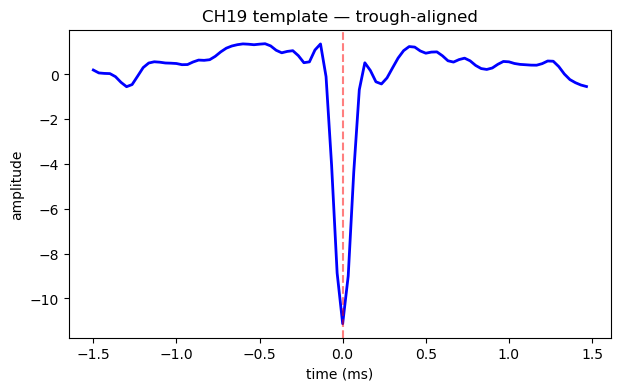

In [82]:
half = 45
search = 30                       # look for the true trough within ±1 ms of the marked time

segs = []
for st in zc_times[:300]:
    idx = int(st * sample_rate)
    # load a wider window so we can search for the trough
    start = idx - half - search
    seg_wide = np.fromfile(ch19_file, dtype='<f8', count=2*half + 2*search, offset=start*8)
    if len(seg_wide) < 2*half + 2*search:
        continue
    # find the true trough near the centre, re-centre on it
    centre = half + search
    local_trough = np.argmin(seg_wide[centre-search:centre+search]) + (centre-search)
    seg = seg_wide[local_trough-half : local_trough+half]
    if len(seg) == 2*half:
        segs.append(seg)

segs = np.array(segs)
template = segs.mean(axis=0)

t_ms = (np.arange(len(template)) - half) / sample_rate * 1000
plt.figure(figsize=(7,4))
plt.plot(t_ms, template, 'b', linewidth=2)
plt.axvline(0, color='r', linestyle='--', alpha=0.5)
plt.title('CH19 template — trough-aligned')
plt.xlabel('time (ms)'); plt.ylabel('amplitude')
plt.show()

In [83]:
np.save(r"C:\spike-denoising-synthetic\data\real\ch19_template.npy", template)
print("template saved")

template saved


In [87]:
from scipy.signal import correlate
import numpy as np

def template_match_fast(signal, template):
    """
    Fast normalised cross correlation (matched filter).
    """
    t = template - template.mean()
    t = t / np.linalg.norm(t)
    n = len(t)

    # numerator: correlation of signal with normalised template
    num = correlate(signal, t, mode='same')

    # denominator: local signal norm (sliding window std)
    sig_sq = correlate(signal**2, np.ones(n), mode='same')
    local_mean = correlate(signal, np.ones(n), mode='same') / n
    local_norm = np.sqrt(np.maximum(sig_sq - n * local_mean**2, 1e-10))

    return num / local_norm

In [88]:
scores = template_match_fast(ch19_win, template)
print("score range:", scores.min(), "to", scores.max())
print("scores shape:", scores.shape)

score range: -0.8057201225072353 to 0.8291437386569516
scores shape: (900000,)


In [91]:
from scipy.signal import find_peaks
# find where the match score peak above a threshold
match_threshold = 0.5
peaks, _ = find_peaks(scores, height=match_threshold, distance=30)

detected_times = peaks / sample_rate + t_start 
print("detections:", len(peaks))
print("ground-truth spikes:", len(gt_in_win))

detections: 2842
ground-truth spikes: 7


In [92]:
# Score aginst ground truth
from src.evaluate import score_detections

p, r, f = score_detections(detected_times, gt_in_win, tolerance=0.002)
print(f"precision {p:.3f}  recall {r:.3f}  F1 {f:.3f}")

precision 0.001  recall 0.429  F1 0.002


In [93]:
for mt in [0.3, 0.4, 0.5, 0.6, 0.7]:
    peaks, _ = find_peaks(scores, height=mt, distance=30)
    det = peaks / sample_rate + t_start
    p, r, f = score_detections(det, gt_in_win, tolerance=0.002)
    print(f"match>{mt}: detected {len(peaks):4d}, precision {p:.3f}, recall {r:.3f}, F1 {f:.3f}")

match>0.3: detected 14190, precision 0.000, recall 1.000, F1 0.001
match>0.4: detected 7713, precision 0.001, recall 0.571, F1 0.001
match>0.5: detected 2842, precision 0.001, recall 0.429, F1 0.002
match>0.6: detected  832, precision 0.001, recall 0.143, F1 0.002
match>0.7: detected  149, precision 0.000, recall 0.000, F1 0.000
